In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def baud_error(clk, baud, oversample=1):
    divider = clk // (baud * oversample)
    divider[divider == 0] = -1
    baud_actual = clk // (divider * oversample)
    err = (baud_actual - baud) / baud * 100
    return err

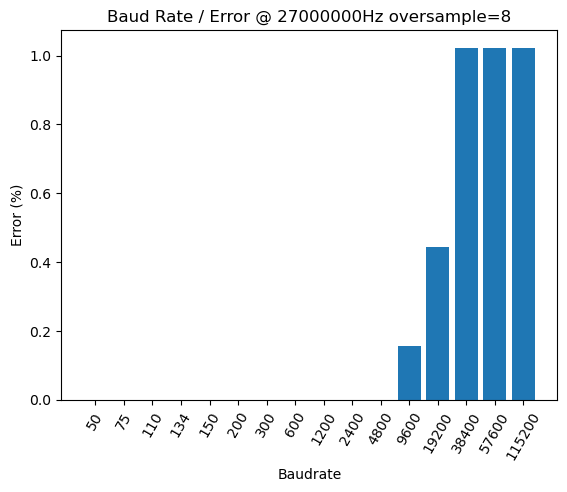

In [28]:
bauds = np.array([50, 75, 110, 134, 150, 200, 300, 600, 1200, 2400, 4800, 9600, 19200, 38400, 57600,
              115200, 230400, 460800, 500000, 576000, 921600, 1000000, 1152000, 1500000,
              2000000, 2500000, 3000000, 3500000, 4000000])

freq = 27_000_000
oversample = 8
errs = baud_error(freq, bauds, oversample)

keep = np.logical_and(0 <= errs, errs <= 3)

bauds = bauds[keep]
errs = errs[keep]

plt.title(f"Baud Rate / Error @ {freq}Hz oversample={oversample}")
plt.bar(bauds.astype(str), errs)
plt.xlabel("Baudrate")
plt.xticks(rotation=60)
plt.ylabel("Error (%)")
plt.show()